##### ARTI 560 - Computer Vision

## Instance Segmentation - Exercise 

### Objective

In this exercise, you will implement **Instance Object Segmentation** using a pretrained **Mask R-CNN model** from TensorFlow Hub.

You will follow these steps:

1. **Load the pretrained Mask R-CNN model**  
   - Use this Kaggle link: [Mask R-CNN Inception-ResNet-v2](https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2)  

2. **Select and load 5 different images**  
   - Choose **5 diverse images**, including:  
      - Crowded scenes with multiple objects  
      - Unusual angles, lighting conditions, or occlusions  
      - At least **one image containing multiple objects of the same class** 

3. **Perform inference using the model**  
   - Feed images to the model to obtain predictions  

4. **Extract prediction outputs**  
   - **Bounding boxes** – coordinates of detected objects  
   - **Class labels** – names of detected objects  
   - **Segmentation masks** – pixel-wise masks for each object  

5. **Visualize the results**  
   - Overlay masks on detected objects  
   - Draw bounding boxes around objects  
   - Display class names and confidence scores  

6. **Experiment with confidence thresholds**  
   - Default threshold: **0.5**  
   - Lower threshold: **0.3** to detect more objects (may include false positives)  

---

- Keep in mind:  
  - Some objects may not be recognized at the default threshold 
  - The model only detects objects from the **COCO dataset (80 classes)**  


In [14]:
import tensorflow as tf
import tensorflow_hub as hub

# 1 Load model
detector = hub.load("https://tfhub.dev/tensorflow/mask_rcnn/inception_resnet_v2_1024x1024/1")

In [16]:
# 2 Load images
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_paths = [
    "/content/lab05-object-segmentation/cars.jpg", # car
    "/content/lab05-object-segmentation/cow.jpg", # cow
    "/content/lab05-object-segmentation/person.jpg", # person
    "/content/lab05-object-segmentation/chair.jpg", # chair
    "/content/lab05-object-segmentation/train.jpg", # train
]

images = []

for path in image_paths:
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)

print("Loaded:", len(images))

Loaded: 5


In [17]:
# 3 Perform Inference
def inference_using_model(image):
    input_tensor = tf.convert_to_tensor(image, dtype=tf.uint8)
    input_tensor = tf.expand_dims(input_tensor, axis=0)
    
    outputs = detector(input_tensor)
    return outputs

In [22]:
# 4 Extract Outputs
def output(outputs, threshold=0.5):
    scores = outputs['detection_scores'][0].numpy()
    boxes = outputs['detection_boxes'][0].numpy()
    classes = outputs['detection_classes'][0].numpy().astype(int)
    masks = outputs['detection_masks'][0].numpy()

    valid = scores >= threshold

    return boxes[valid], classes[valid], scores[valid], masks[valid]

In [23]:
COCO_CLASSES = [
    "background","person","bicycle","car","motorcycle","airplane","bus","train","truck",
    "boat","traffic light","fire hydrant","stop sign","parking meter","bench","bird",
    "cat","dog","horse","sheep","cow","elephant","bear","zebra","giraffe","backpack",
    "umbrella","handbag","tie","suitcase","frisbee","skis","snowboard","sports ball",
    "kite","baseball bat","baseball glove","skateboard","surfboard","tennis racket",
    "bottle","wine glass","cup","fork","knife","spoon","bowl","banana","apple",
    "sandwich","orange","broccoli","carrot","hot dog","pizza","donut","cake","chair",
    "couch","potted plant","bed","dining table","toilet","tv","laptop","mouse",
    "remote","keyboard","cell phone","microwave","oven","toaster","sink",
    "refrigerator","book","clock","vase","scissors","teddy bear","hair drier",
    "toothbrush"
]

In [24]:
# 5 Visualization
def visual(image, boxes, classes, scores, masks):
    h, w, _ = image.shape
    output = image.copy()

    for i in range(len(boxes)):
        y1, x1, y2, x2 = boxes[i]
        y1, x1, y2, x2 = int(y1*h), int(x1*w), int(y2*h), int(x2*w)

        color = np.random.randint(0, 255, (3,), dtype=int)

        # Draw bounding box
        cv2.rectangle(output, (x1, y1), (x2, y2), color.tolist(), 2)

        #  Resize mask to bounding box
        mask = masks[i]
        mask = cv2.resize(mask, (x2 - x1, y2 - y1))

        # Threshold mask
        mask = (mask > 0.5)

        # Create empty full-size mask
        full_mask = np.zeros((h, w), dtype=bool)
        full_mask[y1:y2, x1:x2] = mask

        # Apply mask
        for c in range(3):
            output[:, :, c] = np.where(
                full_mask,
                output[:, :, c] * 0.5 + color[c] * 0.5,
                output[:, :, c]
            )

        # Label
        class_name = COCO_CLASSES[classes[i]]
        label = f"{class_name}: {scores[i]:.2f}"
        cv2.putText(output, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color.tolist(), 2)

    plt.imshow(output)
    plt.axis('off')
    plt.show()

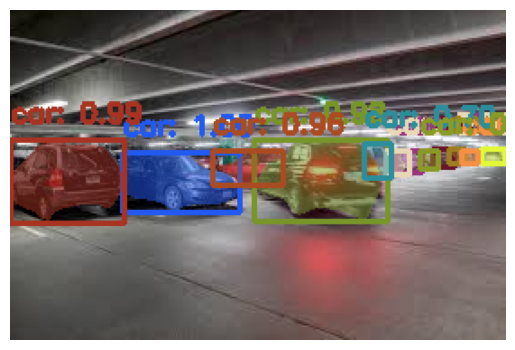

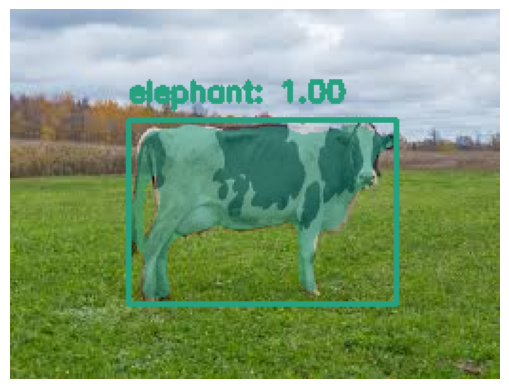

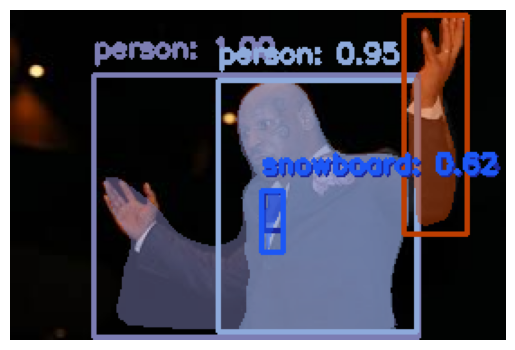

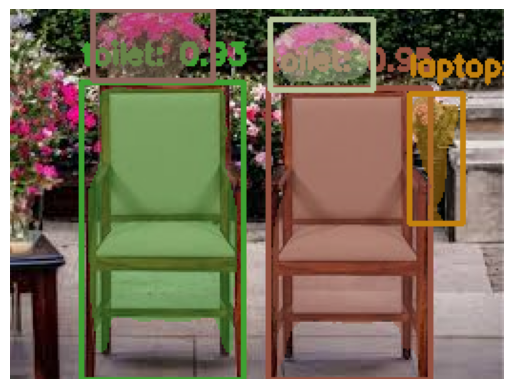

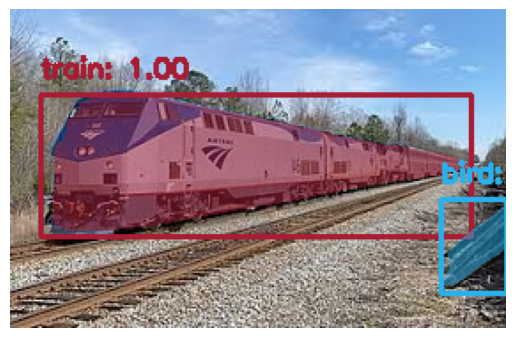

In [25]:
for img in images:
    outputs = inference_using_model(img)
    boxes, classes, scores, masks = output(outputs, threshold=0.5)
    visual(img, boxes, classes, scores, masks)

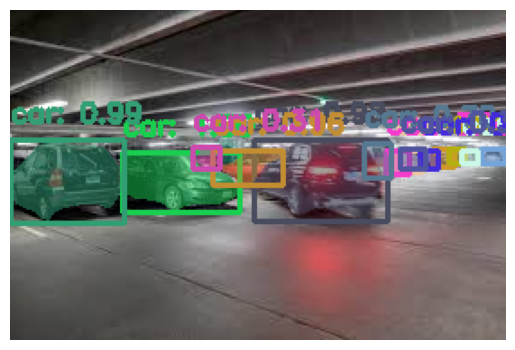

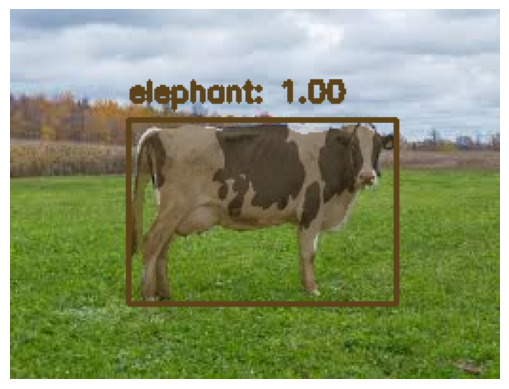

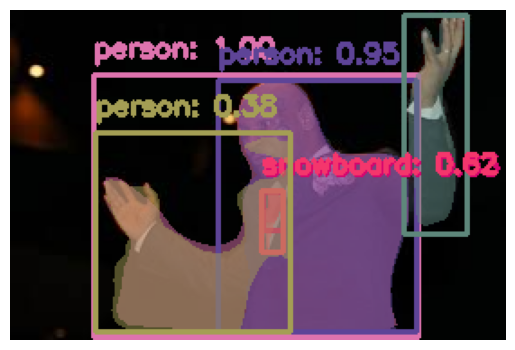

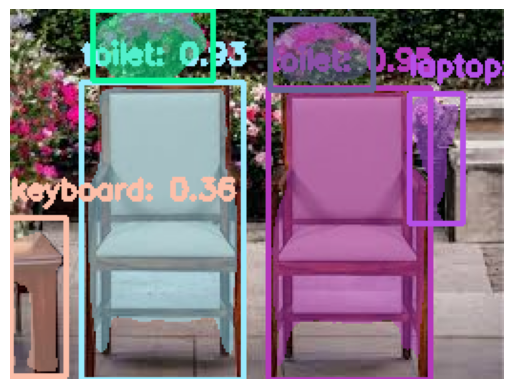

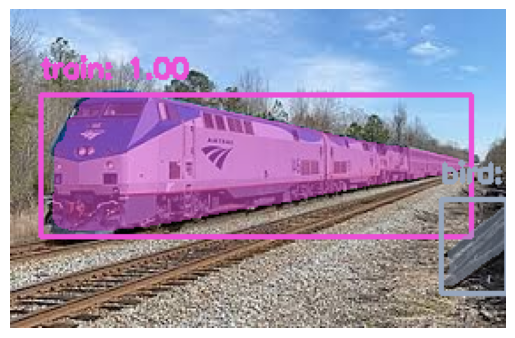

In [26]:
# Lower Threshold
for img in images:
    outputs = inference_using_model(img)
    boxes, classes, scores, masks = output(outputs, threshold=0.3)
    visual(img, boxes, classes, scores, masks)